In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uncertainities_utilities as tp
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr
plt.style.use("../Plotting/paper.mplstyle")

/opt/anaconda3/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
# Setting duration of data and input time of signal to be recovered.

duration = 4
input_time = 2

In [4]:
# Generating a bunch of noise to inject signals into.

np.random.seed(1234)
psd = tp.psd(duration)
noise = [tp.noise(duration, input_psd = psd) for _ in range(10000)]


In [5]:
N_train = 50   # number of random training waveforms
N_val = 20     # number of random validation waveforms

mass_range = (5, 80)      # allowed mass range (solar masses)
distance_range = (100, 6000)  # Mpc


# Generate random component masses where m1 >= m2. Using uniform distribution for simplicity. Could swap to other distributions if desired.

def random_mass_pair(m_min, m_max):
    m1, m2 = np.random.uniform(m_min, m_max, 2)
    return max(m1, m2), min(m1, m2)

# Generate random distance. USing unifrom distribution for simplicity. Coud swap to other distributions if desired.

def random_distance(d_min, d_max):
    return np.random.uniform(d_min, d_max)

# Generate training and validation waveforms with varied parameters.

def generate_waveform_batch(num, prefix):
    wf_dict = {}
    for i in range(num):
        m1, m2 = random_mass_pair(*mass_range)
        d = random_distance(*distance_range)

        key = f"{prefix}_{int(m1)}_{int(m2)}_{int(d)}"
        try:
            wf = tp.waveform(noise[0], m1, m2, d)
            wf_dict[key] = wf
        except Exception as e:
            print(f"Failed to generate {key}: {e}")

    return wf_dict


training_wfs = generate_waveform_batch(N_train, prefix="train")
validation_wfs = generate_waveform_batch(N_val, prefix="val")

print(f"Generated {len(training_wfs)} training waveforms.")
print(f"Generated {len(validation_wfs)} validation waveforms.")

Generated 50 training waveforms.
Generated 20 validation waveforms.


In [6]:
# Organize training and validation results into sorted arrays

training_results = tp.compute_results_for_sets(noise, training_wfs, input_time, duration)
training_arrays = tp.sorted_arrays_from_results(training_results)
training_arrays = tp.apply_datacuts_to_dict(training_arrays)

validation_results = tp.compute_results_for_sets(noise, validation_wfs, input_time, duration)
validation_arrays = tp.sorted_arrays_from_results(validation_results)
validation_arrays = tp.apply_datacuts_to_dict(validation_arrays)

# Combine all training data into single arrays for analysis

all_t = np.concatenate([t for (t,_,_,_) in training_arrays.values()])
all_p = np.concatenate([p for (_,p,_,_) in training_arrays.values()])
all_s = np.concatenate([s for (_,_,s,_) in training_arrays.values()])
all_snr = np.concatenate([snr for (_,_,_,snr) in training_arrays.values()])

In [7]:
# Perform Pearson r test of correlation between uncertainties

print(pearsonr(all_p, all_t))
print(pearsonr(all_s, all_p))
print(pearsonr(all_s, all_t))

PearsonRResult(statistic=np.float64(0.8294176898645521), pvalue=np.float64(0.0))
PearsonRResult(statistic=np.float64(0.0014706149922997095), pvalue=np.float64(0.3031057721144281))
PearsonRResult(statistic=np.float64(0.0022927648454004203), pvalue=np.float64(0.10838238434742749))


490350 490350 490350
330350 330350 330350


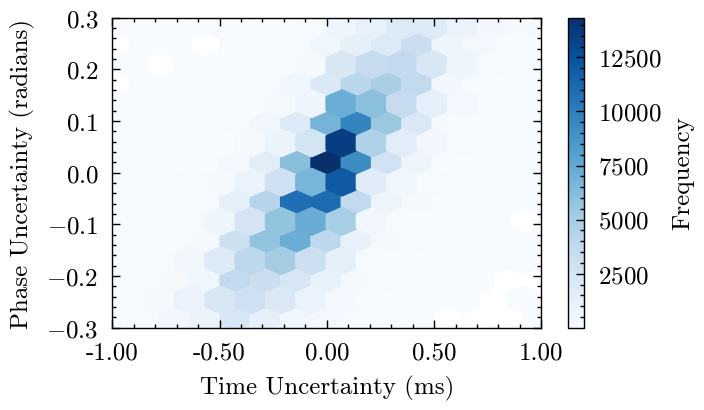

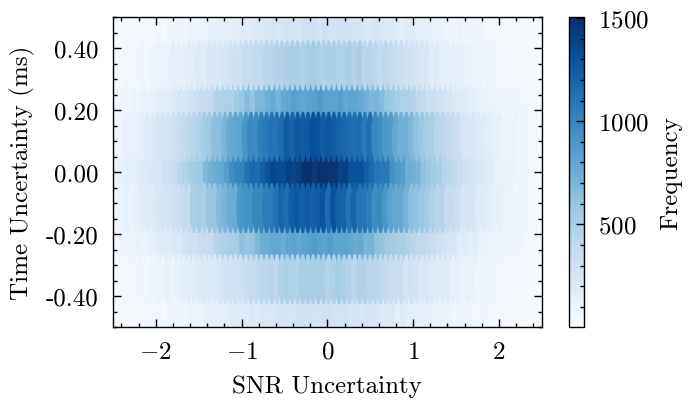

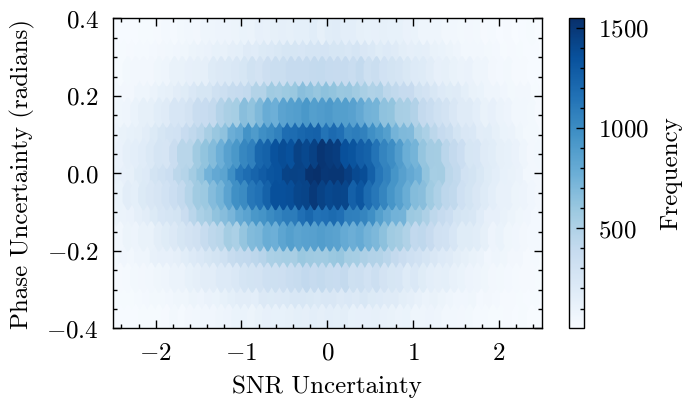

In [8]:
# Hexbin plots for uncertainty correlations

# Remove high SNR points for better visualization since at high SNR all uncertainties are very small
print(len(all_t), len(all_p), len(all_s))
all_t = np.delete(all_t, np.where(all_snr > 20))
all_p = np.delete(all_p, np.where(all_snr > 20))
all_s = np.delete(all_s, np.where(all_snr > 20))

# Custom formatter: convert seconds → ms

print(len(all_t), len(all_p), len(all_s))
def seconds_to_ms(x, pos):
    return f"{x*1000:.2f}"

# --------------------
# Plot 1: Time vs Phase
# --------------------
fig1, ax1 = plt.subplots()

hb1 = ax1.hexbin(all_t, all_p, gridsize=140, mincnt=1, cmap="Blues")
ax1.set_xlabel("Time Uncertainty (ms)")
ax1.set_ylabel("Phase Uncertainty (radians)")
ax1.set_xlim(-0.001, 0.001)
ax1.set_ylim(-0.3, 0.3)
ax1.xaxis.set_major_formatter(FuncFormatter(seconds_to_ms))

cbar1 = fig1.colorbar(hb1, ax=ax1)
cbar1.set_label("Frequency")


fig1.savefig("../Plots/uncertainty_time_phase_hexbin.png")
plt.show()


# --------------------
# Plot 2: SNR vs Time
# --------------------
fig2, ax2 = plt.subplots()

hb2 = ax2.hexbin(all_s, all_t, gridsize=150, mincnt=1, cmap="Blues")
ax2.set_xlabel("SNR Uncertainty")
ax2.set_ylabel("Time Uncertainty (ms)")
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-0.0005, 0.0005)
ax2.yaxis.set_major_formatter(FuncFormatter(seconds_to_ms))
cbar2 = fig2.colorbar(hb2, ax=ax2)
cbar2.set_label("Frequency")


fig2.savefig("../Plots/uncertainty_snr_time_hexbin.png")
plt.show()


# --------------------
# Plot 3: SNR vs Phase
# --------------------
fig3, ax3 = plt.subplots()

hb3 = ax3.hexbin(all_s, all_p, gridsize=100, mincnt=1, cmap="Blues")
ax3.set_xlabel("SNR Uncertainty")
ax3.set_ylabel("Phase Uncertainty (radians)")
ax3.set_xlim(-2.5, 2.5)
ax3.set_ylim(-0.4, 0.4)

cbar3 = fig3.colorbar(hb3, ax=ax3)
cbar3.set_label("Frequency")


fig3.savefig("../Plots/uncertainty_snr_phase_hexbin.png")
plt.show()

In [9]:
# Computing per-waveform standard deviations for time and phase uncertainties, and associated SNR for each waveform.

t_stds = np.array([np.std(t) for (t,_,_,_) in training_arrays.values()])
p_stds = np.array([np.std(p) for (_,p,_,_) in training_arrays.values()])
snrs = np.array([s[0] for (_,_,_,s) in training_arrays.values()])

In [10]:
# Fitting std vs inv SNR

a, b, std, lr_t  = tp.fit_std_vs_inv_snr(t_stds,  snrs, fit_intercept=False)
a2, b2, std2, lr_p = tp.fit_std_vs_inv_snr(p_stds, snrs, fit_intercept=False)

print("t-std fit:", b)
print("p-std fit:", b2)

# model for plotting
snr_range = np.linspace(1, 400, 200)
t_model = b / snr_range
p_model = b2 / snr_range

t-std fit: 0.004668422706936291
p-std fit: 2.0228866529718066


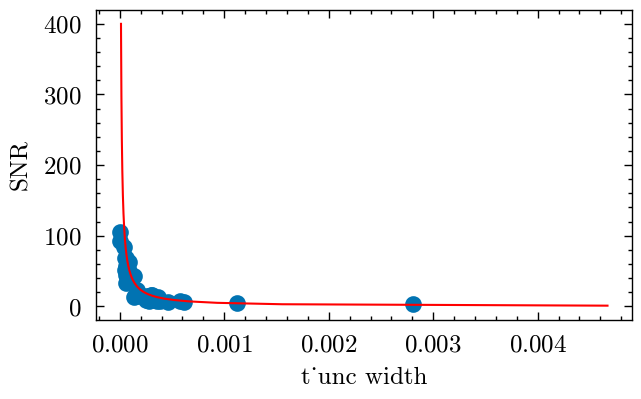

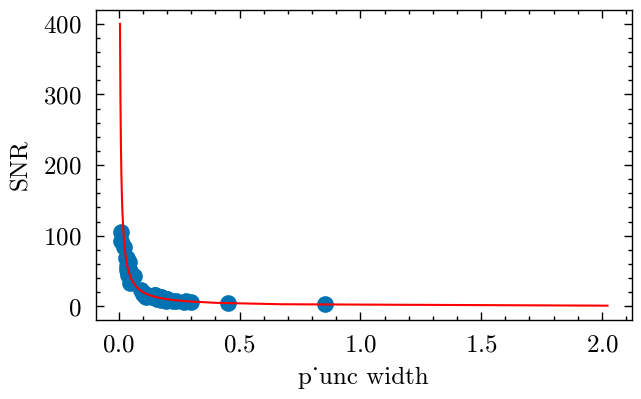

In [11]:
# Plotting traing data and fits

plt.scatter(t_stds, snrs)
plt.plot(t_model,snr_range, color="red")
plt.xlabel("t_unc width")
plt.ylabel("SNR")
plt.show()

plt.scatter(p_stds, snrs)
plt.plot(p_model,snr_range, color="red")
plt.xlabel("p_unc width")


plt.ylabel("SNR")
plt.show()

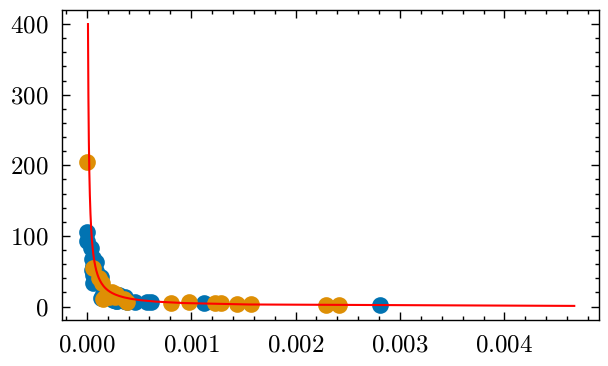

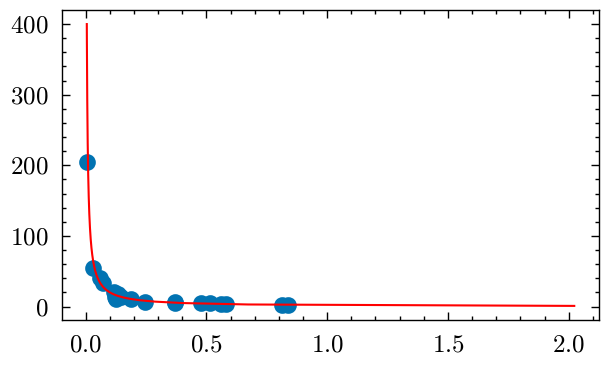

In [12]:
# Now plot validation data against the training fit

val_t_stds = np.array([np.std(t) for (t,_,_,_) in validation_arrays.values()])
val_p_stds = np.array([np.std(p) for (_,p,_,_) in validation_arrays.values()])
val_snrs = np.array([s[0] for (_,_,_,s) in validation_arrays.values()])
plt.scatter(t_stds, snrs)
plt.scatter(val_t_stds,val_snrs)

plt.plot(t_model,snr_range, color="red")
plt.show()
# plt.scatter(p_stds, snrs)
plt.scatter(val_p_stds,val_snrs)

plt.plot(p_model,snr_range, color="red")
plt.show()

In [13]:
# Checking model values for validation data to see how well they match training fit

a, b, std, lr_t  = tp.fit_std_vs_inv_snr(val_t_stds,  val_snrs, fit_intercept=False)
a2, b2, std2, lr_p = tp.fit_std_vs_inv_snr(val_p_stds, val_snrs, fit_intercept=False)
print("t-std fit:", b)
print("p-std fit:", b2)

t-std fit: 0.0059841915592006864
p-std fit: 2.295704216601567


In [14]:
# For phase unceratinty, the validation fit is close to the training fit and the model fits well to the data.
# For time unceratinity the model does not fit well at moderate SNRs. As there is additional dependence on bandwdith.

In [106]:
bandwidth = 1/(2*np.pi*snrs*t_stds)

In [111]:
mask = (snrs > 25) & (bandwidth < 400)  
new_bandwidth = bandwidth[mask]
new_t_stds = t_stds[mask]
new_snrs = snrs[mask]

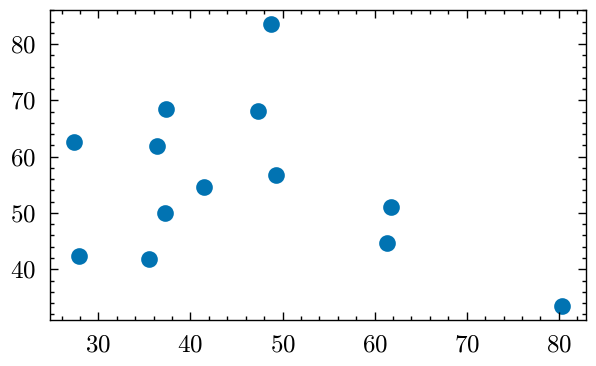

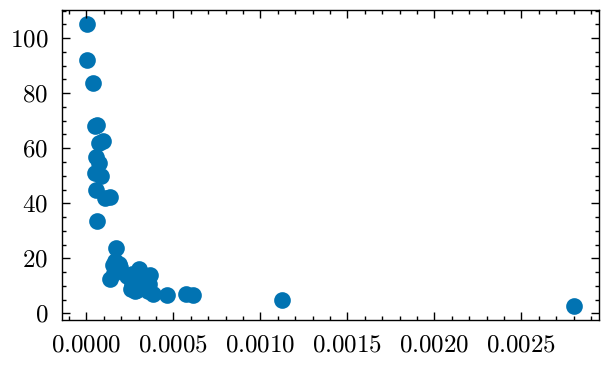

In [112]:
plt.scatter(new_bandwidth, new_snrs)
plt.show()
plt.scatter(t_stds, snrs)
# plt.xlim(0,150)

In [99]:
print(training_arrays.keys())

dict_keys(['train_68_30_941', 'train_56_48_5279', 'train_38_35_5408', 'train_15_12_1669', 'train_48_19_605', 'train_34_11_1714', 'train_75_54_4108', 'train_66_14_4341', 'train_42_40_702', 'train_24_17_4035', 'train_62_21_685', 'train_55_26_3061', 'train_39_5_1607', 'train_35_15_649', 'train_58_46_4687', 'train_56_37_4942', 'train_36_18_624', 'train_72_5_5596', 'train_53_26_2215', 'train_55_19_416', 'train_67_35_829', 'train_61_45_2411', 'train_77_66_1175', 'train_18_5_2094', 'train_57_23_2226', 'train_55_6_1285', 'train_62_34_4711', 'train_56_25_4217', 'train_43_26_2241', 'train_36_36_4170', 'train_61_50_4738', 'train_27_26_5307', 'train_67_16_2985', 'train_77_68_1757', 'train_78_14_689', 'train_21_13_720', 'train_53_12_5610', 'train_63_36_758', 'train_12_11_2132', 'train_48_37_2905', 'train_79_41_3679', 'train_71_38_4390', 'train_47_26_4355', 'train_24_12_227', 'train_57_26_4332', 'train_26_23_3958', 'train_62_14_2591', 'train_17_5_165', 'train_71_64_5054', 'train_36_21_4000'])


In [113]:
def chirp_mass(m1, m2):
    m1 = np.asarray(m1, dtype=float)
    m2 = np.asarray(m2, dtype=float)
    return (m1*m2)**(3/5) / (m1+m2)**(1/5)

def chirp_masses_from_keys(keys):
    m1s, m2s = [], []
    for k in keys:
        parts = k.split("_")
        # expected: ["train", m1, m2, d]
        m1s.append(float(parts[1]))
        m2s.append(float(parts[2]))
    return chirp_mass(np.array(m1s), np.array(m2s))

# keys view -> list (keeps the dict iteration order)
keys_list = list(training_wfs.keys())

chirp_masses = chirp_masses_from_keys(keys_list)

print(chirp_masses.shape)
print(chirp_masses[:10])
new_chirp_masses = chirp_masses[mask]

(50,)
[38.68413456 45.10772154 31.74288623 11.66516135 25.75027921 16.3335452
 55.25289931 25.04869965 35.67983181 17.53231749]


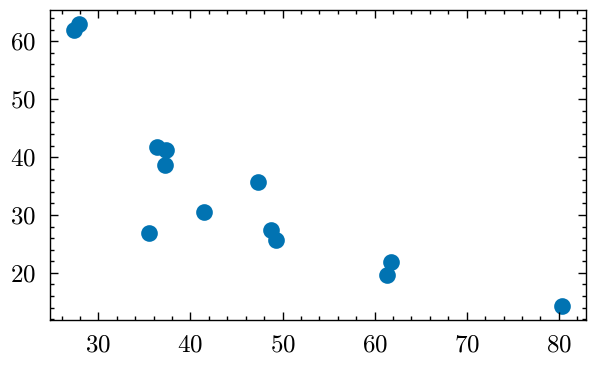

In [114]:
plt.scatter(new_bandwidth, new_chirp_masses)

In [115]:
def total_masses_from_keys(keys):
    m1s, m2s = [], []
    for k in keys:
        _, m1, m2, _ = k.split("_")
        m1s.append(float(m1))
        m2s.append(float(m2))
    return np.array(m1s) + np.array(m2s)

keys_list = list(training_wfs.keys())
total_masses = total_masses_from_keys(keys_list)

print(total_masses.shape)
print(total_masses[:10])
new_total_masses = total_masses[mask]

(50,)
[ 98. 104.  73.  27.  67.  45. 129.  80.  82.  41.]


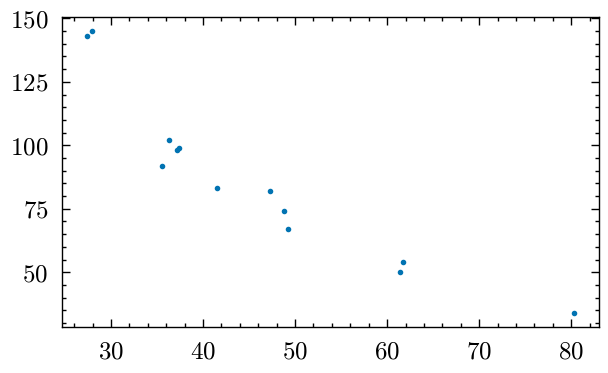

In [116]:
plt.scatter(new_bandwidth, new_total_masses, s=1)

In [117]:
x, y, z, z2  = tp.fit_std_vs_inv_snr(new_bandwidth,  new_total_masses, fit_intercept=False)
print(y)

3217.8395652350737


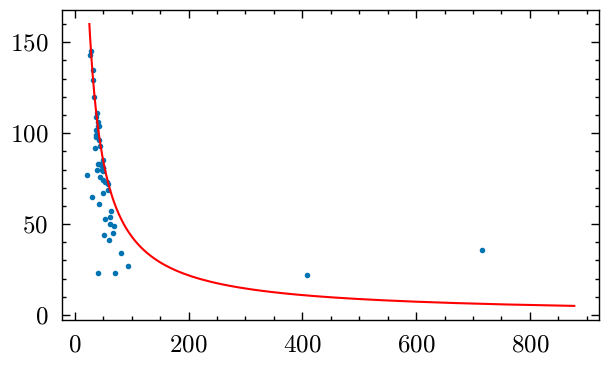

In [141]:
total_mass_range = np.linspace(5, 160, 200)
bandwidth_model = 4400 / (total_mass_range) -2
plt.scatter(bandwidth, total_masses, s=1)
plt.plot(bandwidth_model, total_mass_range, color="red")

In [532]:
import argparse, h5py, numpy as np, pycbc.detector, logging
from numpy.random import uniform, normal
from copy import deepcopy
from collections import defaultdict
from pycbc.waveform import get_fd_waveform
from pycbc.psd import aLIGOZeroDetHighPower
from scipy.interpolate import RectBivariateSpline



def bandwidth(m1,m2,f_lower=20.0, delta_f=1/4):
    hp, hc = get_fd_waveform(approximant="IMRPhenomXPHM",
                            mass1=m1, mass2=m2,
                            f_lower=f_lower,
                            delta_f=delta_f,
                            f_final = 56
)
    f = hp.sample_frequencies.numpy()
    h_abs2 = np.abs(hp.numpy())**2
    psd = aLIGOZeroDetHighPower(len(hp), hp.delta_f, f_lower)
    psd=psd.numpy()
    mask = (f >= f_lower) & (psd > 0) & np.isfinite(psd)
    f, w = f[mask], h_abs2[mask] / psd[mask]
    norm = np.sum(w) * delta_f                      
    f_mean  = (np.sum(f * w) * delta_f) / norm      
    f2_mean = (np.sum((f**2) * w) * delta_f) / norm
    bw2 = f2_mean - f_mean**2
    bw = np.sqrt(max(float(bw2), 0.0))
    return bw

""" Building Interpolation Grid """

grid_points = 40  
m_range = np.linspace(1, 80, grid_points)
z_grid = np.zeros((grid_points, grid_points))

for i, mi in enumerate(m_range):
    for j, mj in enumerate(m_range):
        if mj > mi: 
            z_grid[i, j] = bandwidth(mj, mi) 
        else:
            z_grid[i, j] = bandwidth(mi, mj)
interp_func = RectBivariateSpline(m_range, m_range, z_grid)


   

In [533]:
d = {ifo: pycbc.detector.Detector(ifo) for ifo in ["H1", "V1"]}
""" Mass Model """
size=10000000
m1_samples = np.random.uniform(1, 80, size=size)
m2_samples = np.random.uniform(1, 80, size=size)
# Ensure m1 >= m2 for consistency
mask = m2_samples > m1_samples
m1_samples[mask], m2_samples[mask] = m2_samples[mask], m1_samples[mask]

def chirp_mass(m1, m2):
    return (m1 * m2)**(3/5) / (m1 + m2)**(1/5)


""" Distance Model """

D_max=100 * np.min([0.94,0.32])
uniform_random = np.random.uniform(0, 1, size=size)
distance = D_max * (uniform_random)**(1/3) 


""" Measuring Bandwidths """

bw = interp_func.ev(m1_samples, m2_samples)


""" Signal Location and Orientation """

ra = uniform(0, 2 * np.pi, size=size)
dec = np.arccos(uniform(-1., 1., size=size)) - np.pi/2
inc = np.arccos(uniform(-1., 1., size=size))
pol = uniform(0, 2 * np.pi, size=size)
ic = np.cos(inc)
ip = 0.5 * (1.0 + ic * ic)



# calculate the toa, poa, and amplitude of each sample,
# including uncertainties in measurements.
data = {}
for rs, ifo in zip([0.94,0.32], ["H1","V1"]):
    data[ifo] = {}
    fp, fc = d[ifo].antenna_pattern(ra, dec, pol, 0)
    sp, sc = fp * ip, fc * ic
    data[ifo]['amp'] = (sp**2+sc**2)**0.5*rs #Amplitude without uncertainities
    snr_sp = (rs*chirp_mass(m1_samples, m2_samples)**(5/4)*sp/distance) 
    snr_sc = (rs*chirp_mass(m1_samples, m2_samples)**(5/4)*sc/distance) 
    data[ifo]['op'] = np.arctan2(snr_sc, snr_sp) #Phase without uncertainties
    fsize = snr_sp.shape
    # Add noise to the SNR measurements
    normal_sp = normal(scale=1, size=fsize)
    normal_sc = normal(scale=1, size=fsize)
    snr_sp += normal_sp
    snr_sc += normal_sc
    data[ifo]['snr'] = (snr_sp**2+snr_sc**2)**0.5
    # Add noise to the phase and time measurements
    # Values obtained from modelling time and phase unc, t_unc given by Fairhurst 2009
    p_unc = 2.2/data[ifo]['snr']
    t_unc = 1/(2*np.pi*bw*data[ifo]['snr'])
    rho = 0.86
    # Cholensky Decomposition
    l22_factor = np.sqrt(1.0 - rho**2)
    z_p = normal(size=fsize)
    z_t = normal(size=fsize)
    normal_dp = p_unc * z_p
    normal_dt = (rho * t_unc * z_p) + (t_unc * l22_factor * z_t)
    data[ifo]['p'] = (data[ifo]['op'] + normal_dp) % (2. * np.pi)
    data[ifo]['ot'] = d[ifo].time_delay_from_earth_center(ra, dec, 0) 
    data[ifo]['t'] = d[ifo].time_delay_from_earth_center(ra, dec, 0) + normal_dt
bind56 = []
keep = None
ifo0 = "H1"
ifo1 = "V1"
dt = (data[ifo0]['t'] - data[ifo1]['t'])
dp = (data[ifo0]['p'] - data[ifo1]['p']) % (2. * np.pi)
sr = np.log(data[ifo1]['snr'] / data[ifo0]['snr'])
dtbin = dt
dpbin = dp
srbin = sr
bind56 += [dtbin, dpbin, srbin]
    
        
# Measure network SNR.
snrs_sq=np.zeros(len(data[ifo0]['snr']))
for ifo in ["H1","V1"]:
    snrs_sq += data[ifo]['snr']**2
net_snr = snrs_sq**0.5

# Applying thresholding, individual detector SNR > 5,
# network SNR > 9.
keep = None 
for ifo in ["H1","V1"]:
    if keep is None:
        keep = (net_snr >= 9) & (data[ifo]['snr']>= 5 )
    else:
        keep = keep & (net_snr >= 9) & (data[ifo]['snr']>= 5 )

#Calculate and sum the weights for each bin
# use first ifo as reference for weights
bind56 = [a[keep] for a in bind56]

In [510]:
t_unc = data[ifo0]['ot'][keep] - data[ifo0]['t'][keep]
all_t = np.concatenate([t for (t,_,_,_) in training_arrays.values()])
all_snr = np.concatenate([snr for (_,_,_,snr) in training_arrays.values()])
mask = (all_snr > 5) & (all_snr < 15)
all_t = all_t[mask]
print(max(t_unc), min(t_unc))
print(min(all_t), max(all_t))

0.006362559671041048 -0.005418230440180586
-0.0072021484375 0.0093994140625


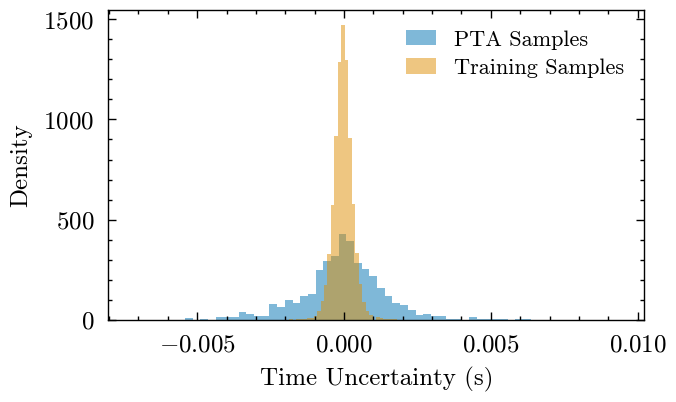

In [511]:
plt.hist(t_unc, bins=45, density=True, alpha=0.5, label="PTA Samples")
plt.hist(all_t, bins=140, density=True, alpha=0.5, label="Training Samples")
plt.xlabel("Time Uncertainty (s)")
plt.ylabel("Density")
plt.legend()

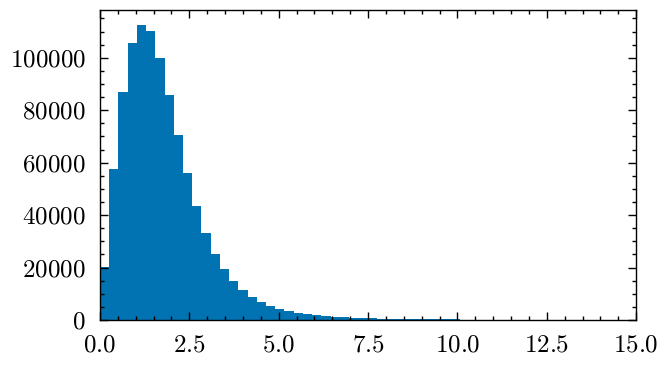

In [512]:
plt.hist(data["H1"]['snr'], bins=500)
plt.xlim(0,15)
plt.show()

In [596]:
size=10000000
ra = uniform(0, 2 * np.pi, size=size)
dec = np.arccos(uniform(-1., 1., size=size)) - np.pi/2
inc = np.arccos(uniform(-1., 1., size=size))
pol = uniform(0, 2 * np.pi, size=size)
ic = np.cos(inc)
ip = 0.5 * (1.0 + ic * ic)
D_max=0.6 * np.min([0.94,0.32])
uniform_random = np.random.uniform(0, 1, size=size)
distance = D_max * (uniform_random)**(1/3) 


# calculate the toa, poa, and amplitude of each sample,
# including uncertainties in measurements.
data = {}
for rs, ifo in zip([0.94,0.32], ["H1","V1"]):
    data[ifo] = {}
    fp, fc = d[ifo].antenna_pattern(ra, dec, pol, 0)
    sp, sc = fp * ip, fc * ic
    data[ifo]['amp'] = (sp**2+sc**2)**0.5*rs #Amplitude without uncertainities
    snr_sp = (rs*sp/distance) 
    snr_sc = (rs*sc/distance) 
    data[ifo]['op'] = np.arctan2(snr_sc, snr_sp) #Phase without uncertainties
    fsize = snr_sp.shape
    # Add noise to the SNR measurements
    normal_sp = normal(scale=1, size=fsize)
    normal_sc = normal(scale=1, size=fsize)
    snr_sp += normal_sp
    snr_sc += normal_sc
    data[ifo]['snr'] = (snr_sp**2+snr_sc**2)**0.5
    # Add noise to the phase and time measurements
    # Values obtained from modelling time and phase unc, t_unc given by Fairhurst 2009
    p_unc = 2.2/data[ifo]['snr']
    t_unc = 1/(2*np.pi*30*data[ifo]['snr'])
    rho = 0.86
    # Cholensky Decomposition
    l22_factor = np.sqrt(1.0 - rho**2)
    z_p = normal(size=fsize)
    z_t = normal(size=fsize)
    normal_dp = p_unc * z_p
    normal_dt = (rho * t_unc * z_p) + (t_unc * l22_factor * z_t)
    data[ifo]['p'] = (data[ifo]['op'] + normal_dp) % (2. * np.pi)
    data[ifo]['t'] = d[ifo].time_delay_from_earth_center(ra, dec, 0) + normal_dt
    

# Organise the data
bind = []
keep = None
ifo0 = "H1"
ifo1 = "V1"

dt = (data[ifo0]['t'] - data[ifo1]['t'])
dp = (data[ifo0]['p'] - data[ifo1]['p']) % (2. * np.pi)
sr = np.log(data[ifo1]['snr'] / data[ifo0]['snr'])
dtbin = dt
dpbin = dp
srbin = sr
snrs = np.array([np.array(data[ifo]["snr"], ndmin=1) for ifo in ["H1", "V1"]])
smin = np.log(snrs.min(axis=0))
bind += [dtbin, dpbin, srbin, smin]
    
        
# Measure network SNR.
snrs_sq=np.zeros(len(data[ifo0]['snr']))
for ifo in ["H1","V1"]:
    snrs_sq += data[ifo]['snr']**2
net_snr = snrs_sq**0.5

# Applying thresholding, individual detector SNR > 5,
# network SNR > 9.
keep = None 
for ifo in ["H1","V1"]:
    if keep is None:
        keep = (net_snr >= 9) & (data[ifo]['snr']>= 4 )
    else:
        keep = keep & (net_snr >= 9) & (data[ifo]['snr']>= 4 )

#Calculate and sum the weights for each bin
# use first ifo as reference for weights
bind = [a[keep] for a in bind]

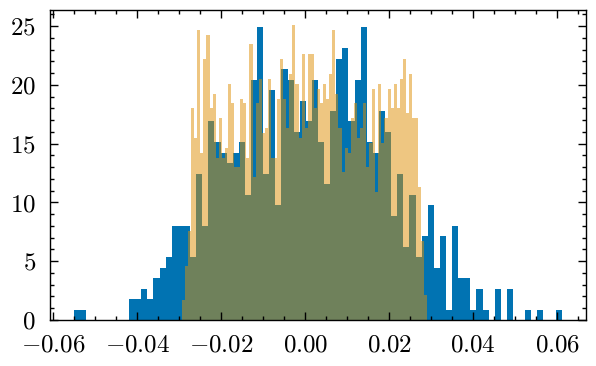

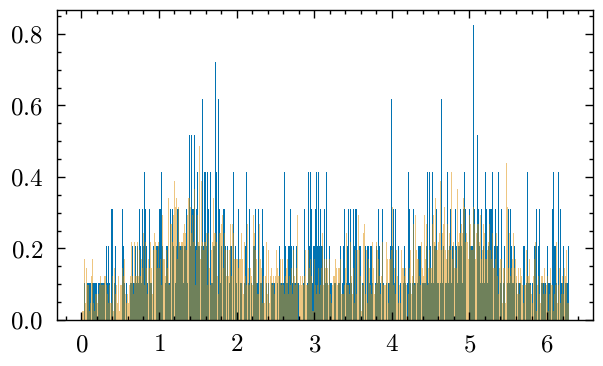

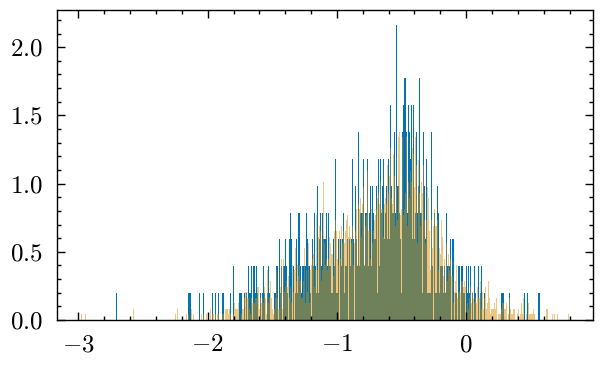

In [ ]:
plt.hist(bind[0], bins=80,  density=True, label="Current")
plt.hist(bind2[0], bins=80, alpha=0.5, density=True, Label="cutoff 29")
plt.show()
plt.hist(bind[1], bins=500, density=True)
plt.hist(bind2[1], bins=500, alpha=0.5  , density=True)
plt.show()
plt.hist(bind[2], bins=500, density=True)
plt.hist(bind2[2], bins=500, alpha=0.5, density=True)
plt.show()

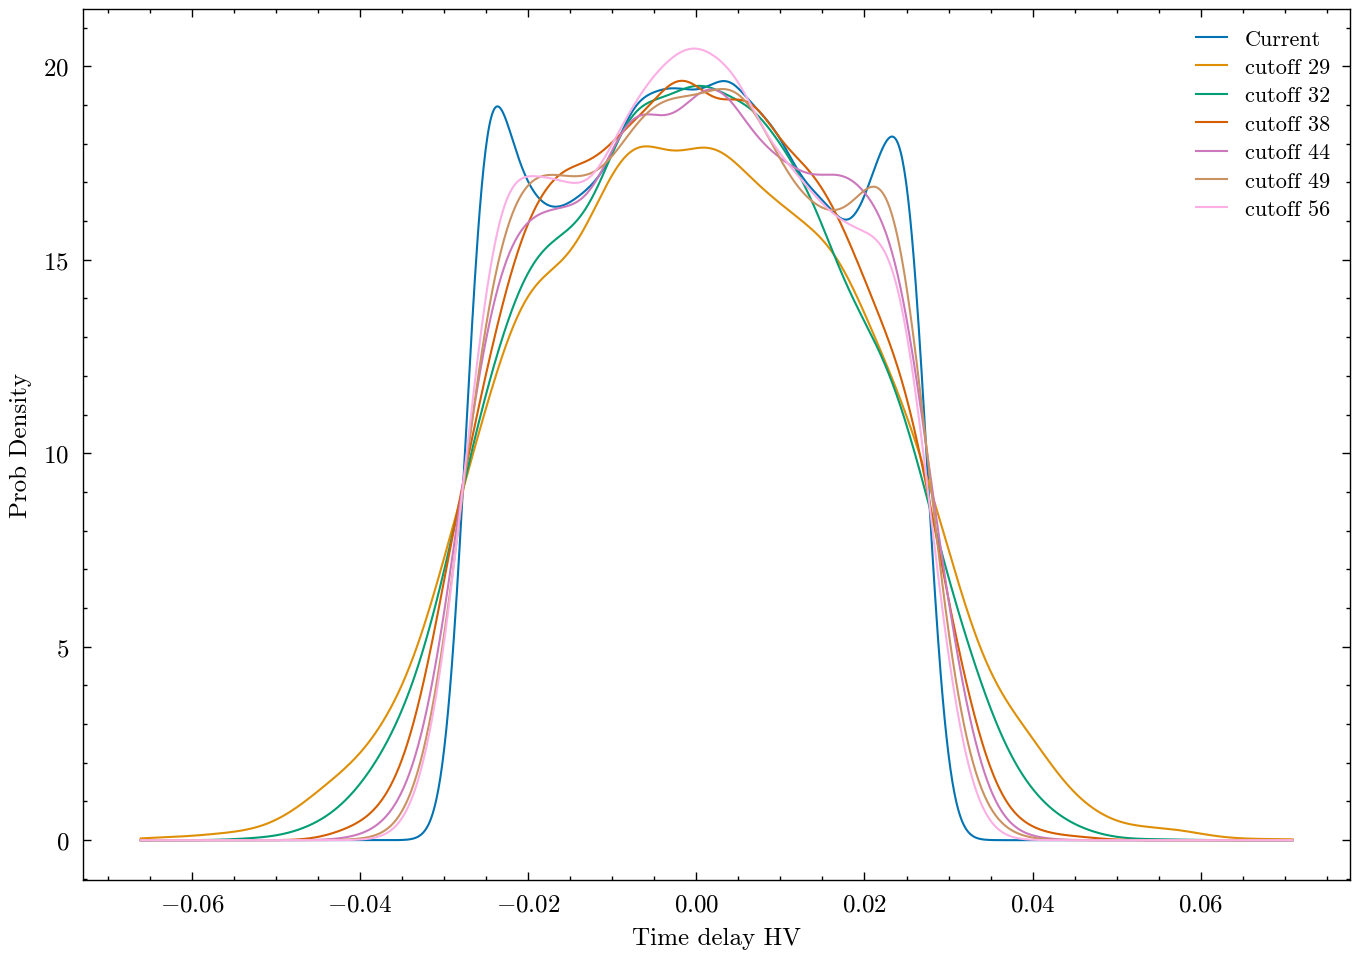

In [536]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

datasets = {
    "Current": bind,
    "cutoff 29": bind29,
    "cutoff 32": bind32,
    "cutoff 38": bind38,
    "cutoff 44": bind44,
    "cutoff 49": bind49,
    "cutoff 56": bind56,
}

# Collect all samples to define a common x-range
all_samples = np.concatenate([d[0] for d in datasets.values()])
x_grid = np.linspace(all_samples.min(), all_samples.max(), 1200)

plt.figure(figsize=(7, 5))

for label, data in datasets.items():
    kde = gaussian_kde(data[0])
    plt.plot(x_grid, kde(x_grid), label=label)

plt.ylabel("Prob Density")
plt.xlabel("Time delay HV")
plt.legend()
plt.tight_layout()

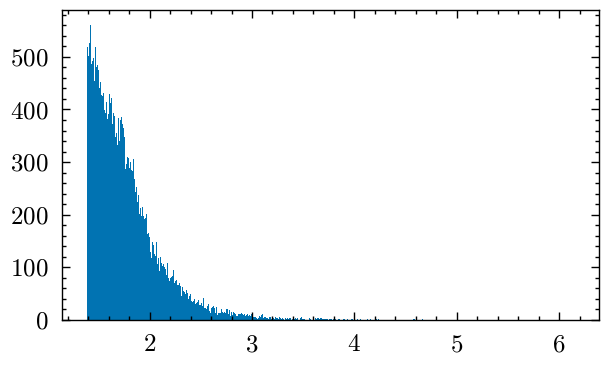

In [597]:
plt.hist(bind[3],bins=1000)

plt.show()

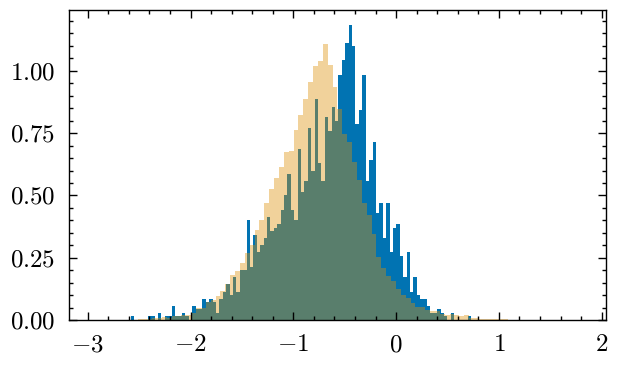

In [612]:
plt.hist(bind[2][mask],bins=100, density = True)
plt.hist(bind[2], bins=100, alpha=0.4, density=True)
plt.show()

In [609]:
mask = bind[3] >2.5